# TCN Regression Training (Phase 2B)

Train a TCN regressor on punch clips to predict peak force (N) and peak speed (m/s).

**Inputs:**
- Punch clips: `data/clips/with_hardware/{class}/{clip_id}.npy`
- Labels: `data/metadata/with_hardware/labels.csv`

**Architecture:** Same TCN as Phase 2A, with two changes:
- Body weight scalar concatenated at the FC layer
- Output: 2 regression values (force, speed) instead of 5 class probabilities
- Loss: MSE

In [20]:
import random
from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")
print(f"PyTorch version: {torch.__version__}")

Using device: cuda
PyTorch version: 2.11.0+cu130


## Configuration

In [21]:
PROJECT_ROOT = Path("../../")

SUBJECTS_CSV = PROJECT_ROOT / "data" / "metadata" / "with_hardware" / "subjects.csv"

CLIPS_DIR = PROJECT_ROOT / "data" / "clips" / "with_hardware"
LABELS_CSV = PROJECT_ROOT / "data" / "metadata" / "with_hardware" / "labels.csv"
MODELS_DIR = PROJECT_ROOT / "models" / "tcn_regression"
MODELS_DIR.mkdir(parents=True, exist_ok=True)

# Model hyperparameters
T = 48                       # window size (frames)
N_JOINTS = 9
N_CHANNELS = 3
N_FEATURES = N_JOINTS * N_CHANNELS   # flattened input dimension

# Training hyperparameters
BATCH_SIZE = 16
LEARNING_RATE = 1e-3
WEIGHT_DECAY = 1e-4
EPOCHS = 100
SEED = 42

# Set seeds for reproducibility
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print(f"Loading labels from: {LABELS_CSV}")
labels_df = pd.read_csv(LABELS_CSV)
print(f"Total clips: {len(labels_df)}")
print(f"Subjects: {sorted(labels_df['subject_id'].unique())}")
print(f"Classes: {sorted(labels_df['class'].unique())}")

Loading labels from: ../../data/metadata/with_hardware/labels.csv
Total clips: 802
Subjects: ['subject01', 'subject02', 'subject03', 'subject04']
Classes: ['cross', 'hook', 'jab', 'uppercut']


## Dataset Class

Loads each punch clip plus its body weight and regression targets.
Applies temporal augmentation (random window placement) during training.

In [22]:
class PunchRegressionDataset(Dataset):
    def __init__(self, df: pd.DataFrame, clips_dir: Path, augment: bool = True):
        self.df = df.reset_index(drop=True)
        self.clips_dir = clips_dir
        self.augment = augment
    
    def __len__(self):
        return len(self.df)
    
    def _pad_or_truncate(self, clip: np.ndarray) -> np.ndarray:
        """Pad or truncate clip to T frames, with optional temporal augmentation."""
        L = clip.shape[0]
        
        if L >= T:
            # Clip is longer than T, just truncate to first T frames
            return clip[:T]
        
        # Clip is shorter than T, need to pad
        if self.augment:
            # Random offset placement
            max_offset = T - L
            offset = random.randint(0, max_offset)
        else:
            offset = 0  # deterministic: clip at start
        
        # Build full T-frame window
        full = np.zeros((T, N_JOINTS, N_CHANNELS), dtype=np.float32)
        
        # Pre-padding: replicate first frame
        if offset > 0:
            full[:offset] = clip[0]
        
        # Place clip
        full[offset:offset + L] = clip
        
        # Post-padding: replicate last frame
        if offset + L < T:
            full[offset + L:] = clip[-1]
        
        return full
    
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        clip_path = self.clips_dir / row["class"] / f"{row['clip_id']}.npy"
        
        clip = np.load(clip_path).astype(np.float32)
        clip = self._pad_or_truncate(clip)
        
        # Reshape to (N_FEATURES, T) for TCN input
        clip = clip.reshape(T, -1).T  # (N_FEATURES, T)
        clip_tensor = torch.from_numpy(clip).float()
        
        # Body weight (auxiliary input)
        body_weight = torch.tensor(row["body_weight_kg"], dtype=torch.float32)
        
        # Targets: force, speed
        targets = torch.tensor([
            row["peak_force_N"],
            row["peak_speed_mps"]
        ], dtype=torch.float32)
        
        return clip_tensor, body_weight, targets


# Verify
ds = PunchRegressionDataset(labels_df, CLIPS_DIR, augment=False)
clip, weight, targets = ds[0]
print(f"Dataset created with {len(ds)} samples")
print(f"Clip shape: {clip.shape} (expecting (27, 48))")
print(f"Body weight shape: {weight.shape}, value: {weight.item():.1f} kg")
print(f"Targets shape: {targets.shape}, values: force={targets[0].item():.1f}N, speed={targets[1].item():.2f}m/s")

Dataset created with 802 samples
Clip shape: torch.Size([27, 48]) (expecting (27, 48))
Body weight shape: torch.Size([]), value: 58.0 kg
Targets shape: torch.Size([2]), values: force=171.0N, speed=3.67m/s


## TCN Regression Architecture

Same TCN as Phase 2A classification, but:
- 2-output regression head instead of 5-class softmax
- Body weight scalar concatenated before the final FC layer

In [23]:
class TCNBlock(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size=5, dilation=1, dropout=0.2):
        super().__init__()
        padding = (kernel_size - 1) * dilation // 2
        self.conv1 = nn.Conv1d(in_channels, out_channels, kernel_size,
                               padding=padding, dilation=dilation)
        self.bn1 = nn.BatchNorm1d(out_channels)
        self.conv2 = nn.Conv1d(out_channels, out_channels, kernel_size,
                               padding=padding, dilation=dilation)
        self.bn2 = nn.BatchNorm1d(out_channels)
        self.dropout = nn.Dropout(dropout)
        if in_channels != out_channels:
            self.residual = nn.Conv1d(in_channels, out_channels, kernel_size=1)
        else:
            self.residual = nn.Identity()
        self.relu = nn.ReLU(inplace=True)
    
    def forward(self, x):
        res = self.residual(x)
        x = self.relu(self.bn1(self.conv1(x)))
        x = self.dropout(x)
        x = self.bn2(self.conv2(x))
        x = self.relu(x + res)
        x = self.dropout(x)
        return x


class TCNRegressor(nn.Module):
    def __init__(self, in_channels=N_FEATURES, channels=[32, 64, 128],
                 kernel_size=5, dropout=0.3, n_outputs=2):
        super().__init__()
        self.data_bn = nn.BatchNorm1d(in_channels)
        layers = []
        prev_channels = in_channels
        for i, ch in enumerate(channels):
            dilation = 2 ** i
            layers.append(TCNBlock(prev_channels, ch, kernel_size, dilation, dropout))
            prev_channels = ch
        self.tcn = nn.Sequential(*layers)
        
        # FC head with body weight concatenated
        self.fc = nn.Sequential(
            nn.Linear(prev_channels + 1, 64),   # +1 for body weight
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            nn.Linear(64, n_outputs),
        )
    
    def forward(self, x, body_weight):
        """
        x: (B, N_FEATURES, T)
        body_weight: (B,) — scalar body weight per sample
        """
        x = self.data_bn(x)
        x = self.tcn(x)
        x = x.mean(dim=2)  # global average pool over time: (B, channels)
        
        # Concatenate body weight as additional feature
        body_weight = body_weight.unsqueeze(1)  # (B, 1)
        x = torch.cat([x, body_weight], dim=1)
        
        x = self.fc(x)  # (B, n_outputs)
        return x


# Test the model
model = TCNRegressor().to(DEVICE)
clip_tensor, weight_tensor, _ = ds[0]
clip_batch = clip_tensor.unsqueeze(0).to(DEVICE)
weight_batch = weight_tensor.unsqueeze(0).to(DEVICE)
with torch.no_grad():
    output = model(clip_batch, weight_batch)
print(f"Model output shape: {output.shape} (expecting (1, 2))")
print(f"Parameters: {sum(p.numel() for p in model.parameters()):,}")

Model output shape: torch.Size([1, 2]) (expecting (1, 2))
Parameters: 184,216


## Training Loop

One pass — single split for initial debugging. Cross-validation comes later.
For now, hold out one subject as test set; train on the rest.

In [24]:
def train_one_epoch(model, loader, optimizer, criterion, device, target_mean, target_std):
    model.train()
    total_loss = 0.0
    n_samples = 0
    for clip, weight, target in loader:
        clip, weight, target = clip.to(device), weight.to(device), target.to(device)
        
        # Normalize targets
        target_norm = (target - target_mean) / target_std
        
        optimizer.zero_grad()
        pred = model(clip, weight)
        loss = criterion(pred, target_norm)
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item() * clip.size(0)
        n_samples += clip.size(0)
    
    return total_loss / n_samples


def evaluate(model, loader, criterion, device, target_mean, target_std):
    model.eval()
    total_loss = 0.0
    n_samples = 0
    all_preds = []
    all_targets = []
    
    with torch.no_grad():
        for clip, weight, target in loader:
            clip, weight, target = clip.to(device), weight.to(device), target.to(device)
            
            # Normalize targets for loss computation
            target_norm = (target - target_mean) / target_std
            
            pred = model(clip, weight)
            loss = criterion(pred, target_norm)
            
            # Denormalize predictions for metrics
            pred_unnorm = pred * target_std + target_mean
            
            total_loss += loss.item() * clip.size(0)
            n_samples += clip.size(0)
            all_preds.append(pred_unnorm.cpu().numpy())
            all_targets.append(target.cpu().numpy())
    
    all_preds = np.vstack(all_preds)
    all_targets = np.vstack(all_targets)
    
    return total_loss / n_samples, all_preds, all_targets

def compute_metrics(preds: np.ndarray, targets: np.ndarray) -> dict:
    """Per-output metrics: MAE, RMSE, R²."""
    metrics = {}
    output_names = ["force_N", "speed_mps"]
    for i, name in enumerate(output_names):
        metrics[f"{name}_mae"] = mean_absolute_error(targets[:, i], preds[:, i])
        metrics[f"{name}_rmse"] = np.sqrt(mean_squared_error(targets[:, i], preds[:, i]))
        metrics[f"{name}_r2"] = r2_score(targets[:, i], preds[:, i])
    return metrics

## Subject-Level Cross-Validation

Proper evaluation: train on N-1 subjects, test on 1, rotate through all subjects.
Each fold tests on a completely unseen subject. This measures real generalization.

Set `RUN_CV = True` to execute (after you have ≥3 subjects in the dataset).

In [25]:
RUN_CV = True  # set to True when you have 3+ subjects annotated

if RUN_CV:
    # Load subject metadata and merge person_id into labels
    subjects_meta = pd.read_csv(SUBJECTS_CSV)
    
    if "person_id" not in subjects_meta.columns:
        raise ValueError(
            "subjects.csv is missing the 'person_id' column. "
            "Add it manually to map subject_id → person_id before running CV."
        )
    
    labels_df_with_person = labels_df.merge(
        subjects_meta[["subject_id", "person_id"]],
        on="subject_id"
    )
    
    persons = sorted(labels_df_with_person["person_id"].unique())
    n_folds = len(persons)
    
    if n_folds < 2:
        raise ValueError(f"Need at least 2 persons for cross-validation, found {n_folds}")
    
    print(f"Running {n_folds}-fold person-level cross-validation")
    print(f"Persons: {persons}")
    print(f"Person-to-subject mapping:")
    for p in persons:
        subs = subjects_meta[subjects_meta["person_id"] == p]["subject_id"].tolist()
        print(f"  {p}: {subs}")
    print()
    
    cv_results = []
    all_preds = []
    all_targets = []
    all_test_persons = []
    
    cv_run_name = f"tcn_reg_cv_{datetime.now().strftime('%Y%m%d_%H%M%S')}"
    cv_dir = MODELS_DIR / cv_run_name
    cv_dir.mkdir(parents=True, exist_ok=True)
    
    for fold_idx, test_person in enumerate(persons):
        train_df_fold = labels_df_with_person[
            labels_df_with_person["person_id"] != test_person
        ].copy()
        test_df_fold = labels_df_with_person[
            labels_df_with_person["person_id"] == test_person
        ].copy()
        
        print(f"--- Fold {fold_idx + 1}/{n_folds}: test={test_person} ---")
        print(f"    Train clips: {len(train_df_fold)} | Test clips: {len(test_df_fold)}")
        
        # Compute normalization stats from train only
        target_mean_fold = train_df_fold[["peak_force_N", "peak_speed_mps"]].mean().values
        target_std_fold = train_df_fold[["peak_force_N", "peak_speed_mps"]].std().values
        target_mean_t = torch.tensor(target_mean_fold, dtype=torch.float32).to(DEVICE)
        target_std_t = torch.tensor(target_std_fold, dtype=torch.float32).to(DEVICE)
        
        # Datasets and loaders
        train_ds_fold = PunchRegressionDataset(train_df_fold, CLIPS_DIR, augment=True)
        test_ds_fold = PunchRegressionDataset(test_df_fold, CLIPS_DIR, augment=False)
        train_loader_fold = DataLoader(train_ds_fold, batch_size=BATCH_SIZE,
                                        shuffle=True, num_workers=0)
        test_loader_fold = DataLoader(test_ds_fold, batch_size=BATCH_SIZE,
                                       shuffle=False, num_workers=0)
        
        # Fresh model per fold
        model_fold = TCNRegressor().to(DEVICE)
        optimizer_fold = torch.optim.Adam(model_fold.parameters(),
                                          lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
        scheduler_fold = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer_fold, T_max=EPOCHS)
        criterion_fold = nn.MSELoss()
        
        best_fold_loss = float("inf")
        best_fold_preds = None
        best_fold_targets = None
        
        for epoch in range(1, EPOCHS + 1):
            train_loss = train_one_epoch(model_fold, train_loader_fold, optimizer_fold,
                                          criterion_fold, DEVICE, target_mean_t, target_std_t)
            test_loss, preds, targets = evaluate(model_fold, test_loader_fold, criterion_fold,
                                                  DEVICE, target_mean_t, target_std_t)
            scheduler_fold.step()
            
            if test_loss < best_fold_loss:
                best_fold_loss = test_loss
                best_fold_preds = preds.copy()
                best_fold_targets = targets.copy()
                torch.save(model_fold.state_dict(),
                           cv_dir / f"fold{fold_idx + 1}_{test_person}_best.pt")
            
            if epoch % 20 == 0:
                print(f"    Epoch {epoch:3d} | train MSE {train_loss:.3f} | test MSE {test_loss:.3f}")
        
        # Compute metrics for this fold
        fold_metrics = compute_metrics(best_fold_preds, best_fold_targets)
        fold_metrics["fold"] = fold_idx + 1
        fold_metrics["test_person"] = test_person
        fold_metrics["n_test_clips"] = len(test_df_fold)
        cv_results.append(fold_metrics)
        
        all_preds.append(best_fold_preds)
        all_targets.append(best_fold_targets)
        all_test_persons.extend([test_person] * len(best_fold_targets))
        
        print(f"    Fold {fold_idx + 1} | force MAE {fold_metrics['force_N_mae']:.1f}N "
              f"R² {fold_metrics['force_N_r2']:.3f} | speed MAE {fold_metrics['speed_mps_mae']:.2f}m/s "
              f"R² {fold_metrics['speed_mps_r2']:.3f}\n")
    
    # Aggregate across folds
    cv_df = pd.DataFrame(cv_results)
    
    print("=" * 60)
    print("CROSS-VALIDATION SUMMARY")
    print("=" * 60)
    print(f"\nPer-fold metrics:")
    print(cv_df[["fold", "test_person", "n_test_clips",
                 "force_N_mae", "force_N_r2",
                 "speed_mps_mae", "speed_mps_r2"]].to_string(index=False))
    
    print(f"\nAggregate (mean ± std across folds):")
    metric_cols = ["force_N_mae", "force_N_rmse", "force_N_r2",
                   "speed_mps_mae", "speed_mps_rmse", "speed_mps_r2"]
    for col in metric_cols:
        mean_val = cv_df[col].mean()
        std_val = cv_df[col].std()
        print(f"  {col}: {mean_val:.3f} ± {std_val:.3f}")
    
    # Save CV results
    cv_df.to_csv(cv_dir / "cv_results.csv", index=False)
    print(f"\nResults saved to: {cv_dir}")
    
    # Pool all predictions across folds for combined visualization
    pooled_preds = np.vstack(all_preds)
    pooled_targets = np.vstack(all_targets)
else:
    print("Cross-validation skipped (RUN_CV = False).")
    print("Set RUN_CV = True at the top of this cell.")

Running 2-fold person-level cross-validation
Persons: ['person01', 'person02']
Person-to-subject mapping:
  person01: ['subject01', 'subject02', 'subject03']
  person02: ['subject04']

--- Fold 1/2: test=person01 ---
    Train clips: 241 | Test clips: 561
    Epoch  20 | train MSE 0.288 | test MSE 3.922
    Epoch  40 | train MSE 0.264 | test MSE 3.527
    Epoch  60 | train MSE 0.221 | test MSE 3.240
    Epoch  80 | train MSE 0.179 | test MSE 3.692
    Epoch 100 | train MSE 0.186 | test MSE 3.754
    Fold 1 | force MAE 49.4N R² -0.335 | speed MAE 1.07m/s R² -0.292

--- Fold 2/2: test=person02 ---
    Train clips: 561 | Test clips: 241
    Epoch  20 | train MSE 0.215 | test MSE 1.225
    Epoch  40 | train MSE 0.173 | test MSE 1.291
    Epoch  60 | train MSE 0.151 | test MSE 1.201
    Epoch  80 | train MSE 0.126 | test MSE 1.140
    Epoch 100 | train MSE 0.127 | test MSE 1.308
    Fold 2 | force MAE 45.3N R² -1.668 | speed MAE 0.78m/s R² 0.002

CROSS-VALIDATION SUMMARY

Per-fold metrics:


## Cross-Validation Visualization

Pooled predictions across all folds, plus per-fold metric comparison.

/tmp/ipykernel_136296/2723045881.py:74: UserWarning: Glyph 128078 (\N{THUMBS DOWN SIGN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_136296/2723045881.py:75: UserWarning: Glyph 128078 (\N{THUMBS DOWN SIGN}) missing from font(s) DejaVu Sans.
  plt.savefig(cv_dir_local / "cv_predictions.png", dpi=120, bbox_inches="tight")
/home/ju/.pyenv/versions/3.12.0/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128078 (\N{THUMBS DOWN SIGN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


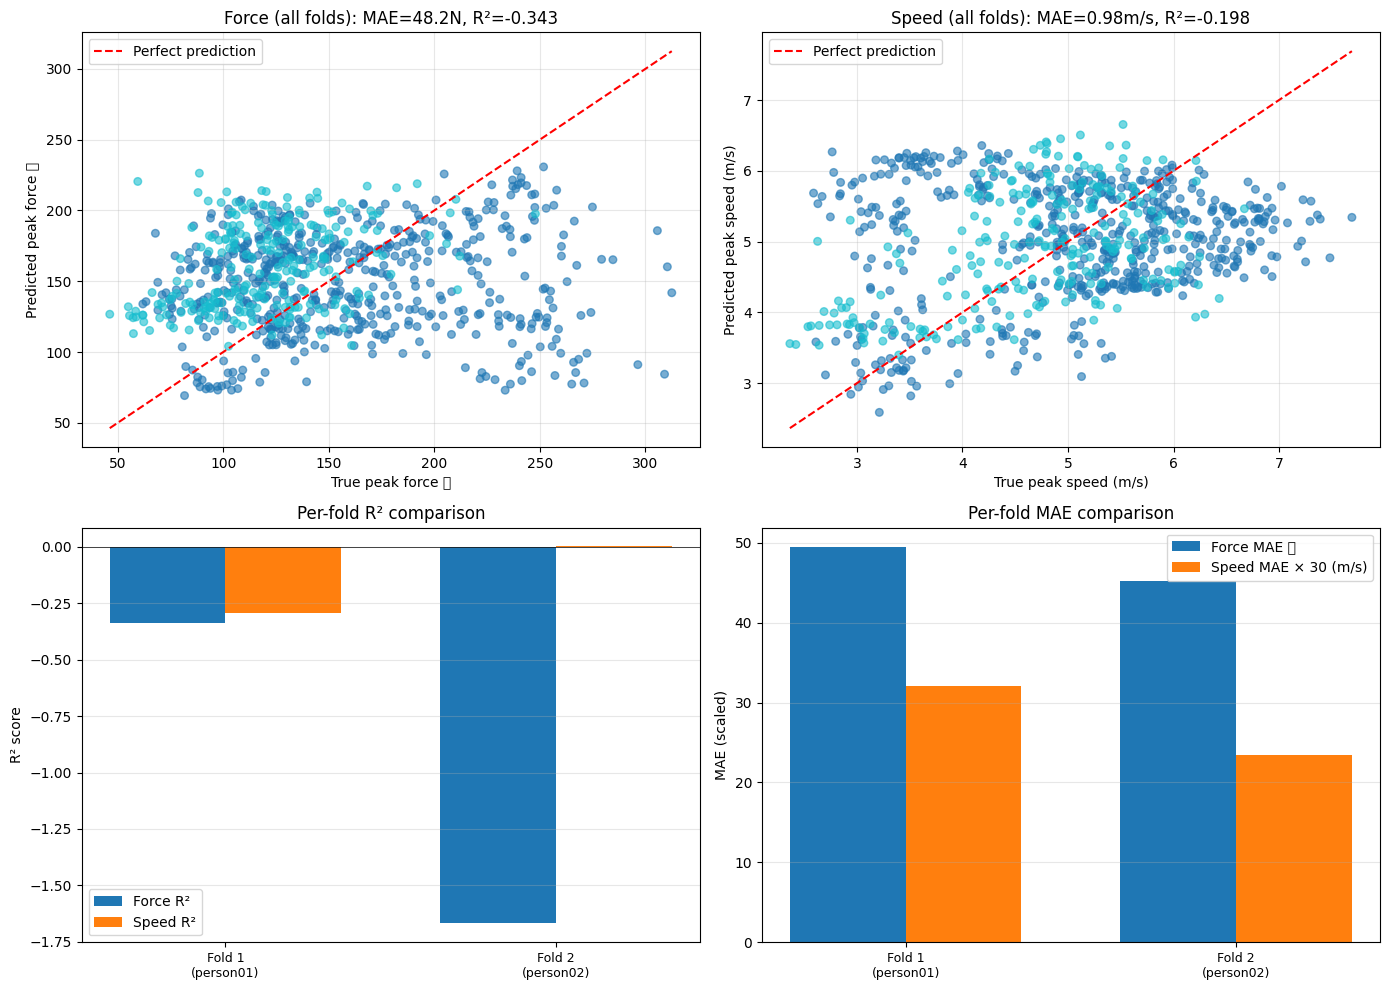


Person color legend (in pooled scatter):
  person01: [0.12156863 0.46666667 0.70588235 1.        ]
  person02: [0.09019608 0.74509804 0.81176471 1.        ]


In [26]:
run_cv = globals().get("RUN_CV", False)
cv_results_local = globals().get("cv_results", [])
pooled_preds_local = globals().get("pooled_preds", None)
pooled_targets_local = globals().get("pooled_targets", None)
all_test_persons_local = globals().get("all_test_persons", [])
cv_dir_local = globals().get("cv_dir", None)

if run_cv and len(cv_results_local) > 0 and pooled_preds_local is not None and pooled_targets_local is not None:
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    
    # Build colors from the actual cross-validation labels we collected
    test_persons = [r["test_person"] for r in cv_results_local]
    unique_persons = sorted(set(test_persons))
    person_colors = plt.cm.tab10(np.linspace(0, 1, len(unique_persons)))
    color_map = dict(zip(unique_persons, person_colors))
    colors_per_point = [color_map[p] for p in all_test_persons_local]
    
    # Pooled force predictions
    ax = axes[0, 0]
    ax.scatter(pooled_targets_local[:, 0], pooled_preds_local[:, 0],
               c=colors_per_point, alpha=0.6, s=30)
    min_val, max_val = pooled_targets_local[:, 0].min(), pooled_targets_local[:, 0].max()
    ax.plot([min_val, max_val], [min_val, max_val], "r--", label="Perfect prediction")
    ax.set_xlabel("True peak force 👎")
    ax.set_ylabel("Predicted peak force 👎")
    pooled_force_r2 = r2_score(pooled_targets_local[:, 0], pooled_preds_local[:, 0])
    pooled_force_mae = mean_absolute_error(pooled_targets_local[:, 0], pooled_preds_local[:, 0])
    ax.set_title(f"Force (all folds): MAE={pooled_force_mae:.1f}N, R²={pooled_force_r2:.3f}")
    ax.legend()
    ax.grid(alpha=0.3)
    
    # Pooled speed predictions
    ax = axes[0, 1]
    ax.scatter(pooled_targets_local[:, 1], pooled_preds_local[:, 1],
               c=colors_per_point, alpha=0.6, s=30)
    min_val, max_val = pooled_targets_local[:, 1].min(), pooled_targets_local[:, 1].max()
    ax.plot([min_val, max_val], [min_val, max_val], "r--", label="Perfect prediction")
    ax.set_xlabel("True peak speed (m/s)")
    ax.set_ylabel("Predicted peak speed (m/s)")
    pooled_speed_r2 = r2_score(pooled_targets_local[:, 1], pooled_preds_local[:, 1])
    pooled_speed_mae = mean_absolute_error(pooled_targets_local[:, 1], pooled_preds_local[:, 1])
    ax.set_title(f"Speed (all folds): MAE={pooled_speed_mae:.2f}m/s, R²={pooled_speed_r2:.3f}")
    ax.legend()
    ax.grid(alpha=0.3)
    
    # Per-fold R² comparison
    ax = axes[1, 0]
    fold_labels = [f"Fold {r['fold']}\n({r['test_person']})" for r in cv_results_local]
    x = np.arange(len(fold_labels))
    width = 0.35
    ax.bar(x - width/2, [r["force_N_r2"] for r in cv_results_local], width, label="Force R²")
    ax.bar(x + width/2, [r["speed_mps_r2"] for r in cv_results_local], width, label="Speed R²")
    ax.set_xticks(x)
    ax.set_xticklabels(fold_labels, fontsize=9)
    ax.set_ylabel("R² score")
    ax.set_title("Per-fold R² comparison")
    ax.axhline(0, color="black", linewidth=0.5)
    ax.legend()
    ax.grid(alpha=0.3, axis="y")
    
    # Per-fold MAE comparison
    ax = axes[1, 1]
    ax.bar(x - width/2, [r["force_N_mae"] for r in cv_results_local], width, label="Force MAE 👎")
    ax.bar(x + width/2,
           [r["speed_mps_mae"] * 30 for r in cv_results_local],  # scale speed for visibility
           width, label="Speed MAE × 30 (m/s)")
    ax.set_xticks(x)
    ax.set_xticklabels(fold_labels, fontsize=9)
    ax.set_ylabel("MAE (scaled)")
    ax.set_title("Per-fold MAE comparison")
    ax.legend()
    ax.grid(alpha=0.3, axis="y")
    
    plt.tight_layout()
    plt.savefig(cv_dir_local / "cv_predictions.png", dpi=120, bbox_inches="tight")
    plt.show()
    
    # Legend for person colors
    print("\nPerson color legend (in pooled scatter):")
    for person, color in color_map.items():
        print(f"  {person}: {color}")
else:
    print("Run the cross-validation cell first to generate pooled predictions and visualizations.")

## Within-Person Session-Level Cross-Validation

Each person was recorded across multiple session sets (subject01-03 for person01, 
subject04-05 for person02). This evaluation measures whether the model can predict 
a person's punches in a held-out session, with training on their other sessions plus 
the other person's data.

This tests within-person generalization across recording conditions while still 
using all available data efficiently.

Set `RUN_WITHIN_PERSON_CV = True` to execute.

In [27]:
RUN_WITHIN_PERSON_CV = True

if RUN_WITHIN_PERSON_CV:
    # Load metadata if not already loaded
    if "subjects_meta" not in dir():
        subjects_meta = pd.read_csv(SUBJECTS_CSV)
    
    if "person_id" not in subjects_meta.columns:
        raise ValueError(
            "subjects.csv is missing the 'person_id' column. "
            "Add it manually to map subject_id → person_id before running CV."
        )
    
    # Merge person_id into labels (if not already done)
    if "person_id" not in labels_df.columns:
        labels_df_wp = labels_df.merge(
            subjects_meta[["subject_id", "person_id"]],
            on="subject_id"
        )
    else:
        labels_df_wp = labels_df.copy()
    
    # Each subject_id is a session for its person; hold one out at a time
    all_subject_ids = sorted(labels_df_wp["subject_id"].unique())
    n_wp_folds = len(all_subject_ids)
    
    print(f"Running {n_wp_folds}-fold within-person session-level cross-validation")
    print(f"Session structure:")
    for p in sorted(labels_df_wp["person_id"].unique()):
        sessions = subjects_meta[subjects_meta["person_id"] == p]["subject_id"].tolist()
        print(f"  {p}: {sessions}")
    print()
    print(f"Each fold holds out one session, trains on all other data")
    print()
    
    wp_results = []
    wp_all_preds = []
    wp_all_targets = []
    wp_all_test_sessions = []
    wp_all_test_persons = []
    
    wp_run_name = f"tcn_reg_wpcv_{datetime.now().strftime('%Y%m%d_%H%M%S')}"
    wp_dir = MODELS_DIR / wp_run_name
    wp_dir.mkdir(parents=True, exist_ok=True)
    
    for fold_idx, test_session in enumerate(all_subject_ids):
        # Look up which person this session belongs to
        test_person = subjects_meta[
            subjects_meta["subject_id"] == test_session
        ]["person_id"].iloc[0]
        
        train_df_fold = labels_df_wp[labels_df_wp["subject_id"] != test_session].copy()
        test_df_fold = labels_df_wp[labels_df_wp["subject_id"] == test_session].copy()
        
        print(f"--- Fold {fold_idx + 1}/{n_wp_folds}: test={test_session} (person={test_person}) ---")
        print(f"    Train clips: {len(train_df_fold)} | Test clips: {len(test_df_fold)}")
        
        # Compute normalization stats from train only
        target_mean_fold = train_df_fold[["peak_force_N", "peak_speed_mps"]].mean().values
        target_std_fold = train_df_fold[["peak_force_N", "peak_speed_mps"]].std().values
        target_mean_t = torch.tensor(target_mean_fold, dtype=torch.float32).to(DEVICE)
        target_std_t = torch.tensor(target_std_fold, dtype=torch.float32).to(DEVICE)
        
        # Datasets and loaders
        train_ds_fold = PunchRegressionDataset(train_df_fold, CLIPS_DIR, augment=True)
        test_ds_fold = PunchRegressionDataset(test_df_fold, CLIPS_DIR, augment=False)
        train_loader_fold = DataLoader(train_ds_fold, batch_size=BATCH_SIZE,
                                        shuffle=True, num_workers=0)
        test_loader_fold = DataLoader(test_ds_fold, batch_size=BATCH_SIZE,
                                       shuffle=False, num_workers=0)
        
        # Fresh model per fold
        model_fold = TCNRegressor().to(DEVICE)
        optimizer_fold = torch.optim.Adam(model_fold.parameters(),
                                          lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
        scheduler_fold = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer_fold, T_max=EPOCHS)
        criterion_fold = nn.MSELoss()
        
        best_fold_loss = float("inf")
        best_fold_preds = None
        best_fold_targets = None
        
        for epoch in range(1, EPOCHS + 1):
            train_loss = train_one_epoch(model_fold, train_loader_fold, optimizer_fold,
                                          criterion_fold, DEVICE, target_mean_t, target_std_t)
            test_loss, preds, targets = evaluate(model_fold, test_loader_fold, criterion_fold,
                                                  DEVICE, target_mean_t, target_std_t)
            scheduler_fold.step()
            
            if test_loss < best_fold_loss:
                best_fold_loss = test_loss
                best_fold_preds = preds.copy()
                best_fold_targets = targets.copy()
                torch.save(model_fold.state_dict(),
                           wp_dir / f"fold{fold_idx + 1}_{test_session}_best.pt")
            
            if epoch % 20 == 0:
                print(f"    Epoch {epoch:3d} | train MSE {train_loss:.3f} | test MSE {test_loss:.3f}")
        
        fold_metrics = compute_metrics(best_fold_preds, best_fold_targets)
        fold_metrics["fold"] = fold_idx + 1
        fold_metrics["test_session"] = test_session
        fold_metrics["test_person"] = test_person
        fold_metrics["n_test_clips"] = len(test_df_fold)
        wp_results.append(fold_metrics)
        
        wp_all_preds.append(best_fold_preds)
        wp_all_targets.append(best_fold_targets)
        wp_all_test_sessions.extend([test_session] * len(best_fold_targets))
        wp_all_test_persons.extend([test_person] * len(best_fold_targets))
        
        print(f"    Fold {fold_idx + 1} | force MAE {fold_metrics['force_N_mae']:.1f}N "
              f"R² {fold_metrics['force_N_r2']:.3f} | speed MAE {fold_metrics['speed_mps_mae']:.2f}m/s "
              f"R² {fold_metrics['speed_mps_r2']:.3f}\n")
    
    # Aggregate across folds
    wp_df = pd.DataFrame(wp_results)
    
    print("=" * 60)
    print("WITHIN-PERSON SESSION-LEVEL CV SUMMARY")
    print("=" * 60)
    print(f"\nPer-fold metrics:")
    print(wp_df[["fold", "test_session", "test_person", "n_test_clips",
                 "force_N_mae", "force_N_r2",
                 "speed_mps_mae", "speed_mps_r2"]].to_string(index=False))
    
    # Aggregate by person too
    print(f"\nAggregate by person:")
    for p in sorted(wp_df["test_person"].unique()):
        person_folds = wp_df[wp_df["test_person"] == p]
        print(f"  {p}:")
        print(f"    Force: MAE {person_folds['force_N_mae'].mean():.2f} ± {person_folds['force_N_mae'].std():.2f} N, "
              f"R² {person_folds['force_N_r2'].mean():.3f}")
        print(f"    Speed: MAE {person_folds['speed_mps_mae'].mean():.3f} ± {person_folds['speed_mps_mae'].std():.3f} m/s, "
              f"R² {person_folds['speed_mps_r2'].mean():.3f}")
    
    print(f"\nOverall aggregate (mean ± std across all folds):")
    metric_cols = ["force_N_mae", "force_N_rmse", "force_N_r2",
                   "speed_mps_mae", "speed_mps_rmse", "speed_mps_r2"]
    for col in metric_cols:
        mean_val = wp_df[col].mean()
        std_val = wp_df[col].std()
        print(f"  {col}: {mean_val:.3f} ± {std_val:.3f}")
    
    # Save CV results
    wp_df.to_csv(wp_dir / "wp_cv_results.csv", index=False)
    print(f"\nResults saved to: {wp_dir}")
    
    # Pool all predictions across folds for combined visualization
    wp_pooled_preds = np.vstack(wp_all_preds)
    wp_pooled_targets = np.vstack(wp_all_targets)
else:
    print("Within-person session-level CV skipped (RUN_WITHIN_PERSON_CV = False).")

Running 4-fold within-person session-level cross-validation
Session structure:
  person01: ['subject01', 'subject02', 'subject03']
  person02: ['subject04']

Each fold holds out one session, trains on all other data

--- Fold 1/4: test=subject01 (person=person01) ---
    Train clips: 642 | Test clips: 160
    Epoch  20 | train MSE 0.241 | test MSE 0.747
    Epoch  40 | train MSE 0.197 | test MSE 1.137
    Epoch  60 | train MSE 0.170 | test MSE 0.864
    Epoch  80 | train MSE 0.148 | test MSE 0.944
    Epoch 100 | train MSE 0.146 | test MSE 0.823
    Fold 1 | force MAE 42.8N R² -0.052 | speed MAE 0.57m/s R² -0.148

--- Fold 2/4: test=subject02 (person=person01) ---
    Train clips: 642 | Test clips: 160
    Epoch  20 | train MSE 0.286 | test MSE 3.334
    Epoch  40 | train MSE 0.207 | test MSE 3.011
    Epoch  60 | train MSE 0.195 | test MSE 2.765
    Epoch  80 | train MSE 0.145 | test MSE 2.996
    Epoch 100 | train MSE 0.158 | test MSE 2.892
    Fold 2 | force MAE 70.8N R² -2.864 | sp

## Within-Person CV Visualization

Predictions vs ground-truth colored by held-out session, plus per-fold and per-person summaries.

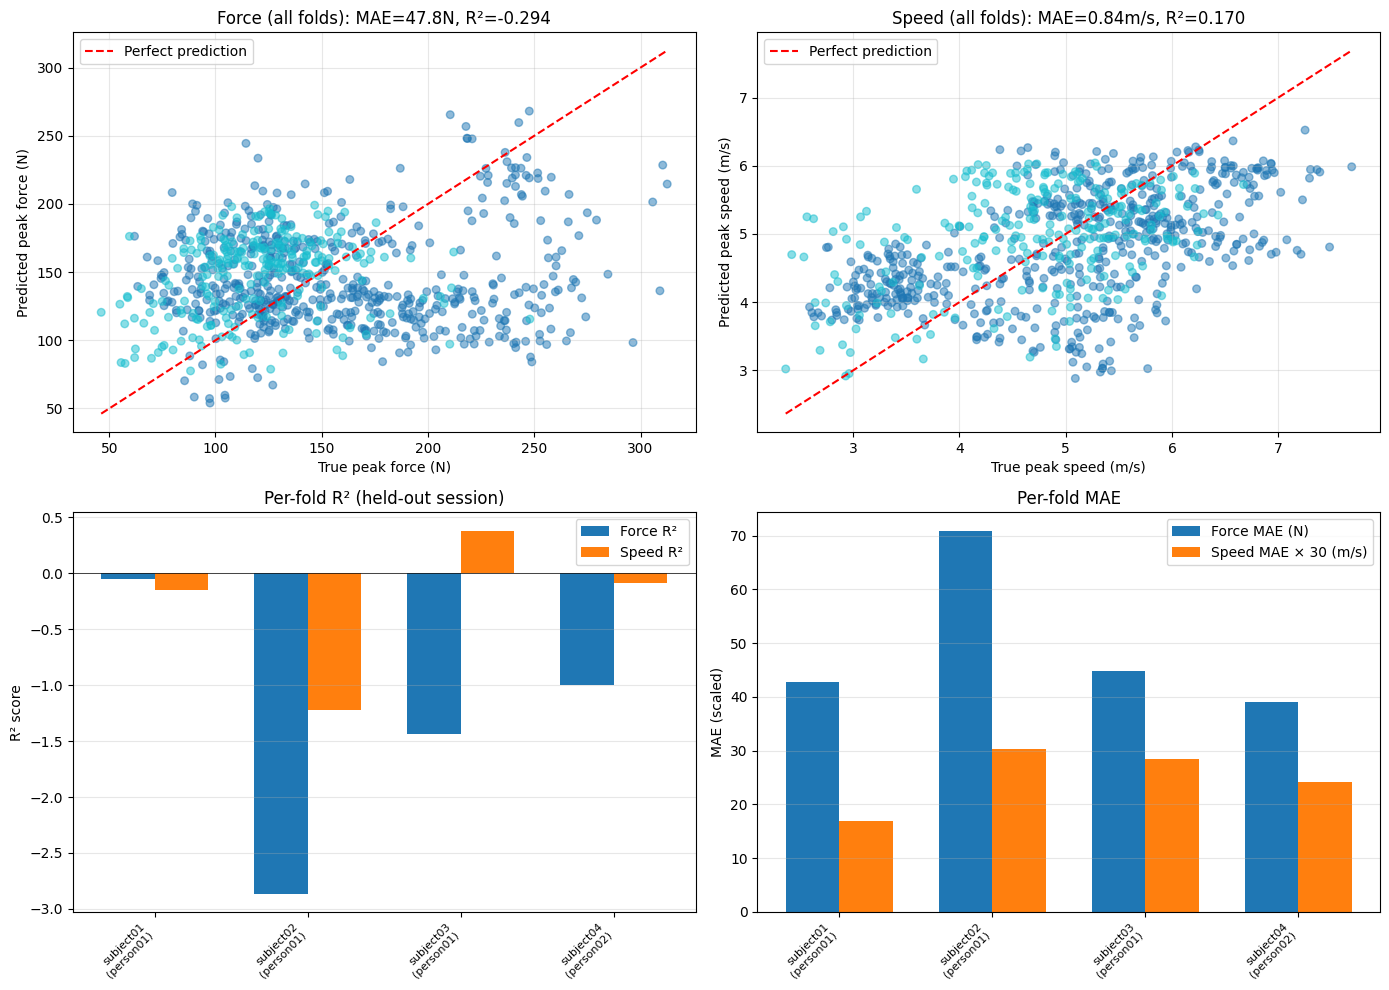


Person color legend (in pooled scatter):
  person01: [0.12156863 0.46666667 0.70588235 1.        ]
  person02: [0.09019608 0.74509804 0.81176471 1.        ]


In [28]:
if RUN_WITHIN_PERSON_CV and len(wp_results) > 0:
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    
    # Pooled force predictions (colored by person)
    ax = axes[0, 0]
    unique_persons = sorted(set(wp_all_test_persons))
    person_colors = plt.cm.tab10(np.linspace(0, 1, max(len(unique_persons), 2)))
    person_color_map = dict(zip(unique_persons, person_colors))
    colors_per_point = [person_color_map[p] for p in wp_all_test_persons]
    
    ax.scatter(wp_pooled_targets[:, 0], wp_pooled_preds[:, 0],
               c=colors_per_point, alpha=0.5, s=30)
    min_val = min(wp_pooled_targets[:, 0].min(), wp_pooled_preds[:, 0].min())
    max_val = max(wp_pooled_targets[:, 0].max(), wp_pooled_preds[:, 0].max())
    ax.plot([min_val, max_val], [min_val, max_val], "r--", label="Perfect prediction")
    ax.set_xlabel("True peak force (N)")
    ax.set_ylabel("Predicted peak force (N)")
    
    from sklearn.metrics import r2_score, mean_absolute_error
    pooled_force_r2 = r2_score(wp_pooled_targets[:, 0], wp_pooled_preds[:, 0])
    pooled_force_mae = mean_absolute_error(wp_pooled_targets[:, 0], wp_pooled_preds[:, 0])
    ax.set_title(f"Force (all folds): MAE={pooled_force_mae:.1f}N, R²={pooled_force_r2:.3f}")
    ax.legend()
    ax.grid(alpha=0.3)
    
    # Pooled speed predictions
    ax = axes[0, 1]
    ax.scatter(wp_pooled_targets[:, 1], wp_pooled_preds[:, 1],
               c=colors_per_point, alpha=0.5, s=30)
    min_val = min(wp_pooled_targets[:, 1].min(), wp_pooled_preds[:, 1].min())
    max_val = max(wp_pooled_targets[:, 1].max(), wp_pooled_preds[:, 1].max())
    ax.plot([min_val, max_val], [min_val, max_val], "r--", label="Perfect prediction")
    ax.set_xlabel("True peak speed (m/s)")
    ax.set_ylabel("Predicted peak speed (m/s)")
    pooled_speed_r2 = r2_score(wp_pooled_targets[:, 1], wp_pooled_preds[:, 1])
    pooled_speed_mae = mean_absolute_error(wp_pooled_targets[:, 1], wp_pooled_preds[:, 1])
    ax.set_title(f"Speed (all folds): MAE={pooled_speed_mae:.2f}m/s, R²={pooled_speed_r2:.3f}")
    ax.legend()
    ax.grid(alpha=0.3)
    
    # Per-fold R² comparison
    ax = axes[1, 0]
    fold_labels = [f"{r['test_session']}\n({r['test_person']})" for r in wp_results]
    x = np.arange(len(fold_labels))
    width = 0.35
    ax.bar(x - width/2, [r["force_N_r2"] for r in wp_results], width, label="Force R²")
    ax.bar(x + width/2, [r["speed_mps_r2"] for r in wp_results], width, label="Speed R²")
    ax.set_xticks(x)
    ax.set_xticklabels(fold_labels, fontsize=8, rotation=45, ha="right")
    ax.set_ylabel("R² score")
    ax.set_title("Per-fold R² (held-out session)")
    ax.axhline(0, color="black", linewidth=0.5)
    ax.legend()
    ax.grid(alpha=0.3, axis="y")
    
    # Per-fold MAE
    ax = axes[1, 1]
    ax.bar(x - width/2, [r["force_N_mae"] for r in wp_results], width, label="Force MAE (N)")
    ax.bar(x + width/2,
           [r["speed_mps_mae"] * 30 for r in wp_results],
           width, label="Speed MAE × 30 (m/s)")
    ax.set_xticks(x)
    ax.set_xticklabels(fold_labels, fontsize=8, rotation=45, ha="right")
    ax.set_ylabel("MAE (scaled)")
    ax.set_title("Per-fold MAE")
    ax.legend()
    ax.grid(alpha=0.3, axis="y")
    
    plt.tight_layout()
    plt.savefig(wp_dir / "wp_cv_predictions.png", dpi=120, bbox_inches="tight")
    plt.show()
    
    print("\nPerson color legend (in pooled scatter):")
    for p, color in person_color_map.items():
        print(f"  {p}: {color}")
else:
    print("Run within-person session-level CV first (Cell 20) to see visualizations.")